In [178]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set()
%matplotlib inline

### data

In [ ]:
# size1 = 1000
# size2 = 3000

# class1 = np.random.normal(loc=-10, scale=5, size=size1)
# class2 = np.random.normal(loc=10, scale=5, size=size2)

# df = pd.DataFrame({'x': np.concatenate([class1, class2]), 'y': [1] * size1 + [2] * size2})

# sns.displot(data_df, kind='kde', x='x', hue='y', fill=True, palette='dark')

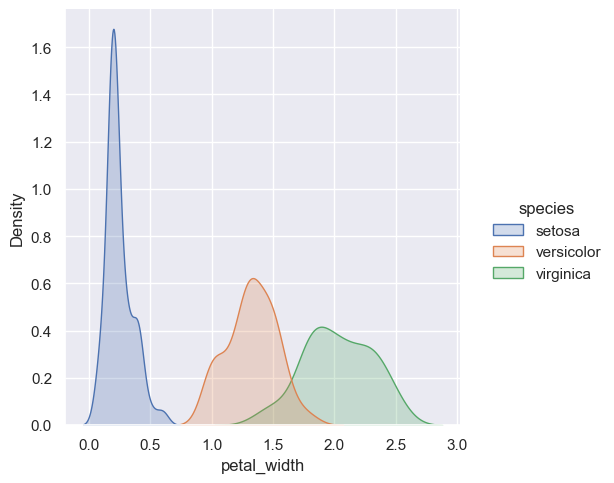

In [299]:
df = sns.load_dataset("iris")

sns.displot(df, kind='kde', x='petal_width', hue='species', fill=True)

### class priors

In [300]:
# priors = {k: df[df.y == k].size / df.size for k in df.y.unique()}  # should be 1/4 and 3/4
priors = {k: df[df.species == k].size / df.size for k in df.species.unique()}
priors

{'setosa': 0.3333333333333333,
 'versicolor': 0.3333333333333333,
 'virginica': 0.3333333333333333}

### univariate mean and standard deviation for each class

In [301]:
# means = {k: df[df.y == k].x.mean() for k in df.y.unique()}  # should be -10 and 10
means = {k: df[df.species == k].petal_width.mean() for k in df.species.unique()}
means

{'setosa': 0.24599999999999997,
 'versicolor': 1.3259999999999998,
 'virginica': 2.0260000000000002}

In [302]:
stdevs = {k: df[df.species == k].petal_width.std() for k in df.species.unique()}  # .std(ddof=0) if not sample
stdevs

{'setosa': 0.10538558938004565,
 'versicolor': 0.19775268000454405,
 'virginica': 0.2746500556366674}

### univariate gaussian PDF

In [303]:
# scipy has gaussian pdf
# from scipy.stats import norm

def univariate_pdf(x, mean, stdev):
    scalar = 1.0 / (stdev * np.sqrt(2 * np.pi))
    exponential = np.exp(-0.5 * ((x - mean) / stdev) ** 2)
    return scalar * exponential

### univariate classifier

In [304]:
species = df.species.unique().tolist()  # returned in order of appearance in DF, static unless DF changes

def nb_classify_uni(x):
    probas = []
    for c in species:
        likelihood = univariate_pdf(x, means[c], stdevs[c])
        # likelihood = norm.pdf(x, means[c], stdevs[c])
        probas.append(likelihood * priors[c])
    return species[np.argmax(probas)]

### univariate decision boundary

In [305]:
sim_data = np.arange(0, 3, 0.01)
sim_classes = [nb_classify_uni(x) for x in sim_data]

species_ints = {c: i for i, c in enumerate(species)}
sim_classes_ints = list(map(species_ints.get, sim_classes))

decision_boundary = np.where(np.array(sim_classes_ints[:-1]) - np.array(sim_classes_ints[1:]) != 0)[0]

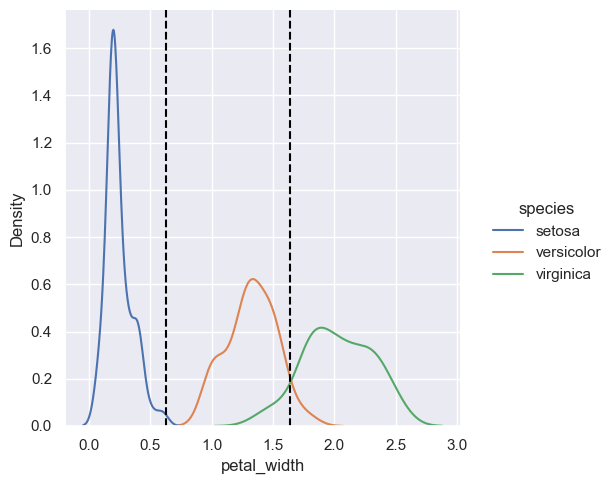

In [306]:
sns.displot(df, kind='kde', x='petal_width', hue='species')

for v in sim_data[decision_boundary]:
    plt.axvline(v, color='black', linestyle='--')

### multivariate

<AxesSubplot:xlabel='petal_width', ylabel='sepal_length'>

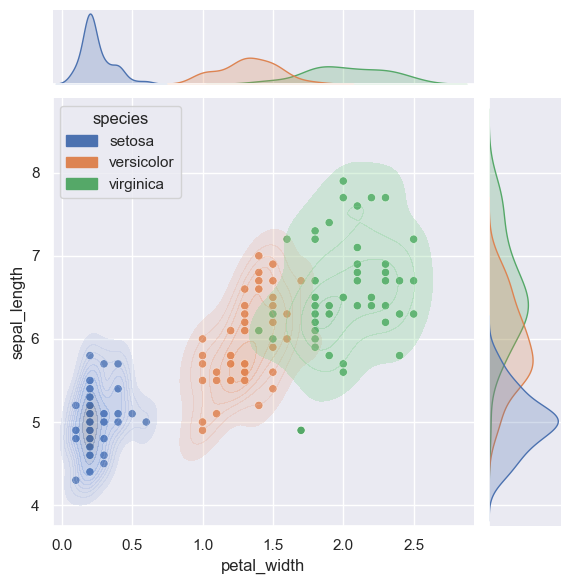

In [371]:
sns.jointplot(df, x='petal_width', y="sepal_length", hue="species")
sns.kdeplot(df, x='petal_width', y="sepal_length", hue="species", alpha=0.3, fill=True)

In [309]:
var_names = ['petal_width', 'sepal_length']

In [310]:
means_multi = {k: df[var_names][df.species == k].mean(axis=0) for k in df.species.unique()}
means_multi

{'setosa': petal_width     0.246
 sepal_length    5.006
 dtype: float64,
 'versicolor': petal_width     1.326
 sepal_length    5.936
 dtype: float64,
 'virginica': petal_width     2.026
 sepal_length    6.588
 dtype: float64}

In [311]:
covars = {k: np.cov(df[var_names][df.species == k], rowvar=False) for k in df.species.unique()}  # bias=True if not sample
covars

{'setosa': array([[0.01110612, 0.01033061],
        [0.01033061, 0.12424898]]),
 'versicolor': array([[0.03910612, 0.05577959],
        [0.05577959, 0.26643265]]),
 'virginica': array([[0.07543265, 0.04909388],
        [0.04909388, 0.40434286]])}

In [312]:
def multivariate_pdf(x, mean, covar):
    dims = x.size
    scalar = np.sqrt(((2 * np.pi) ** dims) * np.linalg.det(covar))
    exponential = np.exp(-0.5 * (x - mean).T @ np.linalg.inv(covar) @ (x - mean))
    return scalar * exponential

In [313]:
def nb_classify_multi(x):
    probas = []
    for c in species:
        likelihood = multivariate_pdf(x, means_multi[c], covars[c])
        probas.append(likelihood * priors[c])
    return species[np.argmax(probas)]

### multivariate decision boundary

In [399]:
sim_data_pw = np.arange(0, 3, 0.10)
sim_data_sl = np.arange(4, 9, 0.20)
sim_data_multi = np.around(np.array([np.array([x_pw, x_sl]) for x_pw in sim_data_pw for x_sl in sim_data_sl]), 1)

sim_classes_multi = [nb_classify_multi(x) for x in sim_data_multi]

In [362]:
# sim_classes_multi_ints = np.array(list(map(species_ints.get, sim_classes_multi)))

# decision_boundary_idxs = np.where(sim_classes_multi_ints[:-1] - sim_classes_multi_ints[1:] != 0)[0]
# decision_boundary = sim_data_multi[decision_boundary_idxs]

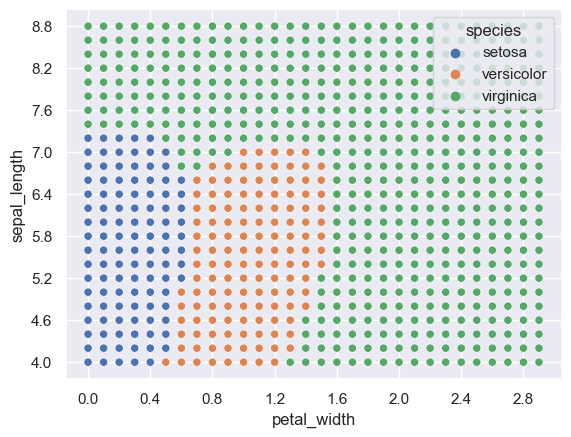

In [401]:
from matplotlib.ticker import MaxNLocator

plot_df = pd.DataFrame(np.hstack([sim_data_multi, np.array(sim_classes_multi).reshape(-1, 1)]), columns=var_names + ['species'])

ax = sns.scatterplot(plot_df, x='petal_width', y="sepal_length", hue="species", hue_order=species)
ax.invert_yaxis()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

In [ ]:
# TODO double check decision boundary: sklearn.naive_bayes.GaussianNB